# VKR — запуск тяжёлых экспериментов на Colab A100  *(V3)*

Этот ноутбук создан для **Google Colab** с **A100 GPU**.

## Текущая задача

- ✅ Fashion-MNIST: уже посчитан (3 seeds × 7 HPO-методов), результаты на Drive.
- ⏳ **Higgs** (≈98k записей из OpenML): **актуальная задача этого ноутбука**.

## Перед запуском

1. **Включить A100**: Runtime → Change runtime type → A100 GPU.
2. **Загрузить архив проекта**: `vkr_project_V3.zip` (или новее).
3. **Подключить Google Drive** — обязательно. Без него прогон при разрыве сеанса
   улетит в никуда. В этой версии есть assert, который не даст пропустить.

## Что нового в V3 (относительно V2)

- `runner.py`: атомарное сохранение результатов через `.tmp`-папку и проверка
  `_is_run_complete`. Прерывание прогона **больше не оставит** битых папок.
- `preprocessing.py`: NaN-imputation (median для числовых, "missing" для категориальных)
  и `np.nan_to_num` для X и y. Higgs больше не должен давать `loss=nan`.
- `adam_random.py`: устойчивость к NaN — если все trials дали NaN, метод не падает.
- Этот ноутбук: Drive **обязателен**, добавлены чекпоинты в Drive каждые N минут.

## 1. Проверка окружения

In [ ]:
!nvidia-smi

Mon May  4 10:05:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
print(f"torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

torch: 2.10.0+cu128
CUDA available: True
Device: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


## 2. Загрузка архива проекта

Загрузите `vkr_project_V3.zip`. Старая папка `/content/vkr` будет удалена,
чтобы исключить смешивание версий.

In [ ]:
!rm -rf /content/vkr
from google.colab import files
print("Загрузите vkr_project_V3.zip:")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f"Загружено: {zip_name}")
!unzip -q "/content/{zip_name}" -d /content/

# В V3 архив распаковывается в vkr_project_V3/vkr/. Если структура другая —
# адаптируем путь. Ищем папку src/, выясняем корень проекта.
import os, glob
candidates = glob.glob('/content/**/src/runner.py', recursive=True)
assert candidates, "Не нашёл src/runner.py в архиве"
PROJECT_ROOT = os.path.dirname(os.path.dirname(candidates[0]))
print(f"Корень проекта: {PROJECT_ROOT}")
# Делаем симлинк /content/vkr -> PROJECT_ROOT для совместимости с прежними путями
if PROJECT_ROOT != '/content/vkr':
    if os.path.lexists('/content/vkr'):
        os.remove('/content/vkr') if os.path.islink('/content/vkr') else __import__('shutil').rmtree('/content/vkr')
    os.symlink(PROJECT_ROOT, '/content/vkr')
    print(f"/content/vkr -> {PROJECT_ROOT}")
!ls /content/vkr/

Загрузите vkr_project_V3.zip:


Saving vkr_project_V3.zip to vkr_project_V3.zip
Загружено: vkr_project_V3.zip
Корень проекта: /content/vkr_project_V3/vkr
/content/vkr -> /content/vkr_project_V3/vkr
docs  notebooks  README.md  requirements.txt  src


## 3. ОБЯЗАТЕЛЬНО — подключение Google Drive

Без Drive результаты пишутся в `/content/`, который очищается при разрыве сеанса.
В V3 есть assert ниже, который остановит запуск, если Drive не подключён.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/vkr_results', exist_ok=True)

# Очищаем локальный results_fixed (если уже создан) и ставим симлинк на Drive
import shutil
local = '/content/vkr/notebooks/results_fixed'
target = '/content/drive/MyDrive/vkr_results'

# Если local — обычная папка с данными, переносим её содержимое на Drive
if os.path.isdir(local) and not os.path.islink(local):
    for item in os.listdir(local):
        src = os.path.join(local, item)
        dst = os.path.join(target, item)
        if not os.path.exists(dst):
            shutil.move(src, dst)
            print(f"  moved {item} -> Drive")
    if not os.listdir(local):
        os.rmdir(local)

# Если local — битый симлинк или просто остался — удаляем
if os.path.lexists(local) and not os.path.exists(local):
    os.remove(local)
elif os.path.isdir(local) and not os.path.islink(local):
    # Что-то осталось внутри (конфликты) — оставляем как есть, но симлинк не сделаем
    print(f"⚠ В {local} остались файлы: {os.listdir(local)}; разберитесь вручную")

# Создаём симлинк
if not os.path.lexists(local):
    os.symlink(target, local)

# Проверка
real = os.path.realpath(local)
print(f"results_fixed -> {real}")
assert "/content/drive/" in real, "Симлинк указывает не на Drive!"
print("✓ Drive подключён, результаты идут в Drive")

Mounted at /content/drive
results_fixed -> /content/drive/MyDrive/vkr_results
✓ Drive подключён, результаты идут в Drive


## 4. Установка зависимостей

In [ ]:
!pip install -q -r /content/vkr/requirements.txt
print("Готово")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 23.9 MB/s eta 0:00:00
Готово


## 5. Импорт пайплайна и safety-checks

После импорта проверяем три вещи:
1. версию `runner.py` (должен быть атомарный `save_run`),
2. `preprocessing.py` (должен быть NaN-патч),
3. что `results_fixed` указывает на Drive.

In [ ]:
import sys
sys.path.insert(0, '/content/vkr')
import os
os.chdir('/content/vkr/notebooks')

from src.config import CONFIG, SEEDS, device, RESULTS_DIR
from src.data import DATASETS
from src.methods import HPO_METHODS, DE_METHODS
from src.runner import run_all, save_run, _is_run_complete  # ← V3 экспортирует _is_run_complete
from src.aggregation import aggregate_results, print_table

# Sanity check 1: версия runner
import inspect
src = inspect.getsource(save_run)
assert "tmp_path" in src and "_is_run_complete" in inspect.getsource(__import__('src.runner', fromlist=['runner'])), \
    "В runner.py нет атомарного save_run / _is_run_complete — обновите архив до V3"
print("✓ runner.py V3 (атомарное save_run)")

# Sanity check 2: NaN-патч в preprocessing
from src.data import preprocessing as _pp
src_pp = inspect.getsource(_pp)
assert "SimpleImputer" in src_pp and "nan_to_num" in src_pp, \
    "В preprocessing.py нет NaN-патча — обновите архив до V3"
print("✓ preprocessing.py V3 (NaN-imputation)")

# Sanity check 3: results_fixed на Drive
real = os.path.realpath('/content/vkr/notebooks/results_fixed')
assert "/content/drive/" in real, f"results_fixed -> {real}, не Drive! Вернитесь к ячейке Drive."
print(f"✓ results_fixed -> {real}")

print(f"\nDevice: {device}")
print(f"HPO methods: {list(HPO_METHODS.keys())}")

✓ runner.py V3 (атомарное save_run)
✓ preprocessing.py V3 (NaN-imputation)
✓ results_fixed -> /content/drive/MyDrive/vkr_results

Device: cuda
HPO methods: ['Adam_baseline', 'Adam_RandomSearch', 'Adam_TPE', 'Adam_GP_BO', 'Adam_Hyperband', 'Adam_BOHB', 'Adam_MFBO']


## 6. Подкручиваем CONFIG под Colab

Параметры — отправная точка под одну сессию A100. Higgs ≈ 98k объектов; одна
эпоха занимает порядка 10-20 секунд на A100, поэтому 5 search_epochs — разумно.

In [ ]:
CONFIG["adam_baseline"]["epochs"] = 20

CONFIG["adam_random"]["n_trials"] = 12
CONFIG["adam_random"]["search_epochs"] = 5
CONFIG["adam_random"]["final_epochs"] = 15

CONFIG["adam_optuna"]["n_trials"] = 12
CONFIG["adam_optuna"]["search_epochs"] = 5
CONFIG["adam_optuna"]["final_epochs"] = 15

CONFIG["adam_gp_bo"]["n_init"] = 4
CONFIG["adam_gp_bo"]["n_trials"] = 12
CONFIG["adam_gp_bo"]["search_epochs"] = 5
CONFIG["adam_gp_bo"]["final_epochs"] = 15

CONFIG["adam_hyperband"]["max_resource"] = 12
CONFIG["adam_hyperband"]["final_epochs"] = 15

CONFIG["adam_bohb"]["n_trials"] = 25
CONFIG["adam_bohb"]["max_resource"] = 12
CONFIG["adam_bohb"]["final_epochs"] = 15

CONFIG["adam_mfbo"]["n_init"] = 4
CONFIG["adam_mfbo"]["n_trials"] = 12
CONFIG["adam_mfbo"]["fidelities"] = [1, 4, 12]
CONFIG["adam_mfbo"]["final_epochs"] = 15

print("CONFIG обновлён под Colab.")

CONFIG обновлён под Colab.


`[42, 123, 2024, 7, 999]`

## 7. Higgs — основной запуск

2 seeds × 7 HPO-методов. На A100 в Colab ориентировочно 3–6 часов.

Если прервётся — можно перезапустить с `skip_existing=True`, V3-runner
корректно продолжит.

In [ ]:
run_all(
    seeds=[42, 123],
    methods=list(HPO_METHODS.keys()),
    datasets=['higgs'],
    skip_existing=True,
)


DATASET: higgs  (kind=tabular, task=classification)

--- seed 42 ---
Shape: in=28 out=2 n_tr=68634 n_val=14708 n_test=14708
  [Adam_baseline] ... 

Adam baseline:   0%|          | 0/20 [00:00<?, ?it/s]

loss=0.5410 acc=0.7239 [54.7s]
  [Adam_RandomSearch] ... 

RS final:   0%|          | 0/15 [00:00<?, ?it/s]

loss=0.5409 acc=0.7193 [175.4s]
  [Adam_TPE] ... 

...

[I 2026-05-04 10:54:30,115] A new study created in memory with name: no-name-ad48242e-285f-423f-9a8c-0fc5c98dc9f9
[I 2026-05-04 10:55:00,473] Trial 0 finished with value: 0.5572054145580599 and parameters: {'h': 396, 'lr': 0.0003062965796384134, 'dropout': 0.11342572678210155}. Best is trial 0 with value: 0.5572054145580599.
[I 2026-05-04 10:55:30,341] Trial 1 finished with value: 0.5463968371125969 and parameters: {'h': 340, 'lr': 0.0016686152127171198, 'dropout': 0.21155323006223048}. Best is trial 1 with value: 0.5463968371125969.
[I 2026-05-04 10:56:00,627] Trial 2 finished with value: 0.5479659353354265 and parameters: {'h': 505, 'lr': 0.001457153097856983, 'dropout': 0.24046595074218047}. Best is trial 1 with value: 0.5463968371125969.
[I 2026-05-04 10:56:10,440] Trial 3 pruned. 
[I 2026-05-04 10:56:40,390] Trial 4 finished with value: 0.5808522057397099 and parameters: {'h': 296, 'lr': 0.0001262963955863223, 'dropout': 0.1990221276652157}. Best is trial 1 with value: 0.546396837

BOHB final:   0%|          | 0/15 [00:00<?, ?it/s]

loss=0.5408 acc=0.7182 [469.4s]
  [Adam_MFBO] ... 

MFBO final:   0%|          | 0/15 [00:00<?, ?it/s]

loss=0.5706 acc=0.7051 [159.9s]


In [ ]:
run_all(
    seeds=[2024, 7, 999],
    methods=list(HPO_METHODS.keys()),
    datasets=['higgs'],
    skip_existing=True,
)


DATASET: higgs  (kind=tabular, task=classification)

--- seed 2024 ---
Shape: in=28 out=2 n_tr=68634 n_val=14708 n_test=14708
  [Adam_baseline] ... 

Adam baseline:   0%|          | 0/20 [00:00<?, ?it/s]

loss=0.5429 acc=0.7204 [50.3s]
  [Adam_RandomSearch] ... 

RS final:   0%|          | 0/15 [00:00<?, ?it/s]

loss=0.6639 acc=0.6971 [178.2s]
  [Adam_TPE] ... 

...

[I 2026-05-04 12:19:28,116] A new study created in memory with name: no-name-f8383b94-5319-46fa-a033-f8d81b98c068
[I 2026-05-04 12:19:58,895] Trial 0 finished with value: 0.5715184356973714 and parameters: {'h': 437, 'lr': 0.000787489110426916, 'dropout': 0.05955573251410601}. Best is trial 0 with value: 0.5715184356973714.
[I 2026-05-04 12:20:04,017] Trial 1 pruned. 
[I 2026-05-04 12:20:34,343] Trial 2 finished with value: 0.5489747458772553 and parameters: {'h': 292, 'lr': 0.0008747518429707117, 'dropout': 0.3140632612387804}. Best is trial 2 with value: 0.5489747458772553.
[I 2026-05-04 12:20:44,401] Trial 3 pruned. 
[I 2026-05-04 12:21:14,465] Trial 4 finished with value: 0.5983893322108198 and parameters: {'h': 259, 'lr': 0.00022001066456294843, 'dropout': 0.35366211505105294}. Best is trial 2 with value: 0.5489747458772553.
[I 2026-05-04 12:21:19,550] Trial 5 pruned. 
[I 2026-05-04 12:21:24,655] Trial 6 pruned. 
[I 2026-05-04 12:21:55,098] Trial 7 finished with value: 0.572054077

BOHB final:   0%|          | 0/15 [00:00<?, ?it/s]

loss=0.5448 acc=0.7239 [474.1s]
  [Adam_MFBO] ... 

MFBO final:   0%|          | 0/15 [00:00<?, ?it/s]

loss=0.5578 acc=0.7134 [160.9s]


In [ ]:
run_all(
    seeds=[2024, 7, 999],
    methods=list(HPO_METHODS.keys()),
    datasets=['fashion_mnist'],
    skip_existing=True,
)


DATASET: fashion_mnist  (kind=image, task=classification)

--- seed 2024 ---


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 279kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.23MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.1MB/s]


Shape: in=28 out=10 n_tr=49412 n_val=10588 n_test=10000
  [Adam_baseline] skip (already exists)
  [Adam_RandomSearch] skip (already exists)
  [Adam_TPE] skip (already exists)
  [Adam_GP_BO] skip (already exists)
  [Adam_Hyperband] skip (already exists)
  [Adam_BOHB] skip (already exists)
  [Adam_MFBO] skip (already exists)

--- seed 7 ---
Shape: in=28 out=10 n_tr=49412 n_val=10588 n_test=10000
  [Adam_baseline] ... 

Adam baseline:   0%|          | 0/20 [00:00<?, ?it/s]

loss=0.3880 acc=0.8910 [242.8s]
  [Adam_RandomSearch] ... 

...

[I 2026-05-04 16:42:49,992] A new study created in memory with name: no-name-0a671426-a368-4419-989b-919ed42ca347
[I 2026-05-04 16:46:14,030] Trial 0 finished with value: 0.49035429774386324 and parameters: {'h': 437, 'lr': 0.000787489110426916, 'dropout': 0.05955573251410601}. Best is trial 0 with value: 0.49035429774386324.
[I 2026-05-04 16:49:13,543] Trial 1 finished with value: 0.3801270673803712 and parameters: {'h': 374, 'lr': 0.00014271817846244806, 'dropout': 0.16611284039650615}. Best is trial 1 with value: 0.3801270673803712.
[I 2026-05-04 16:51:49,987] Trial 2 finished with value: 0.24345929414585576 and parameters: {'h': 292, 'lr': 0.0008747518429707117, 'dropout': 0.3140632612387804}. Best is trial 2 with value: 0.24345929414585576.
[I 2026-05-04 16:52:21,192] Trial 3 pruned. 
[I 2026-05-04 16:54:56,189] Trial 4 finished with value: 0.48399750412658876 and parameters: {'h': 259, 'lr': 0.00022001066456294843, 'dropout': 0.35366211505105294}. Best is trial 2 with value: 0.24

BOHB final:   0%|          | 0/15 [00:00<?, ?it/s]

loss=0.2542 acc=0.9183 [2375.0s]
  [Adam_MFBO] ... 

MFBO final:   0%|          | 0/15 [00:00<?, ?it/s]

loss=0.3048 acc=0.8964 [738.0s]



=== Test Loss (mean ± std по seeds) ===
╒═══════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╤════════════════════════╕
│ Dataset       │ Adam_baseline          │ Adam_RandomSearch      │ Adam_TPE               │ Adam_GP_BO             │ Adam_Hyperband         │ Adam_BOHB              │ Adam_MFBO              │
╞═══════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╪════════════════════════╡
│ HIGGS         │ 0.5409 ± 0.0022  (n=5) │ 0.5670 ± 0.0542  (n=5) │ 0.5672 ± 0.0229  (n=5) │ 0.5618 ± 0.0110  (n=5) │ 0.5436 ± 0.0050  (n=5) │ 0.5436 ± 0.0033  (n=5) │ 0.5642 ± 0.0093  (n=5) │
├───────────────┼────────────────────────┼────────────────────────┼────────────────────────┼────────────────────────┼────────────────────────┼────────────────────────┼────────────────────

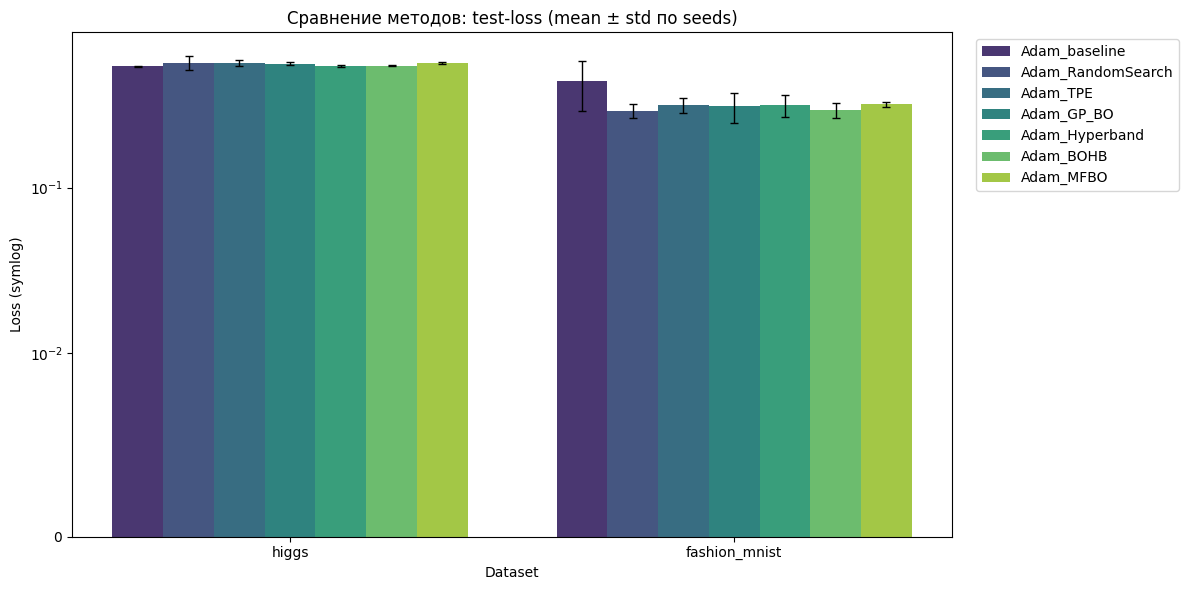

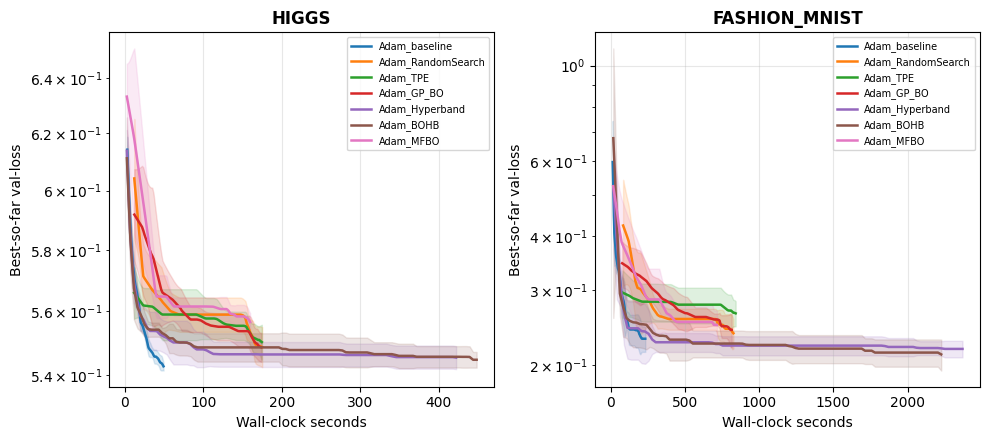

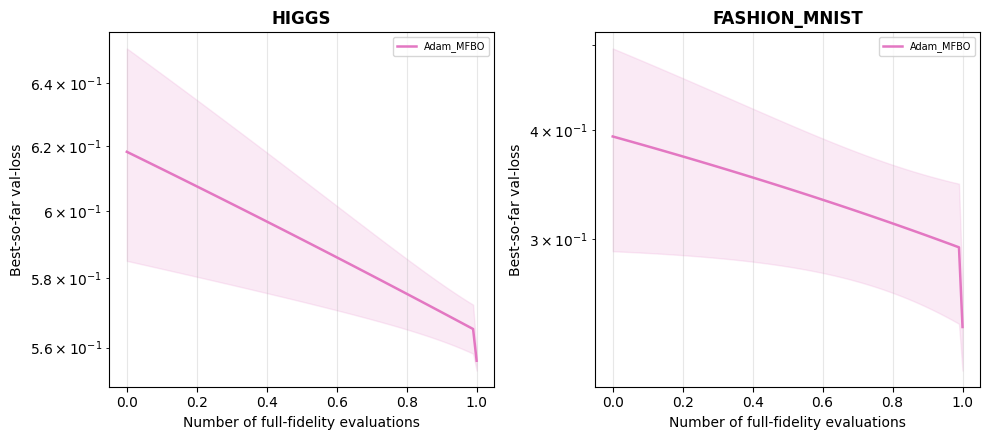

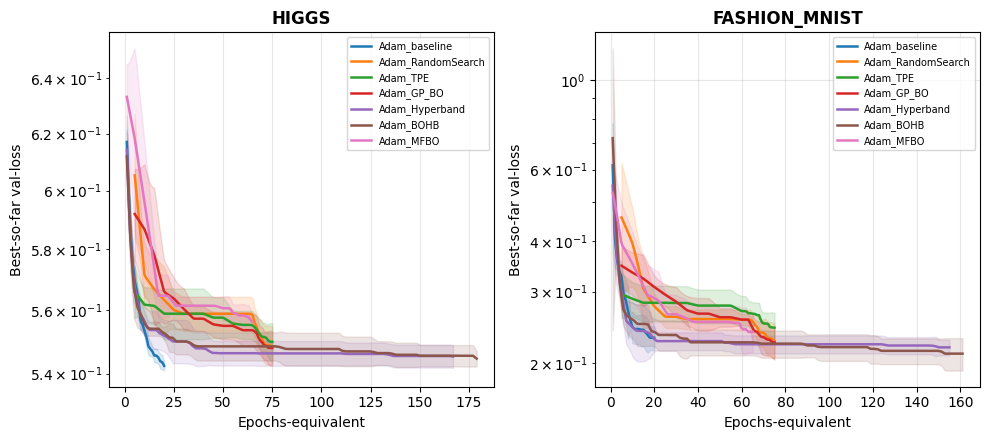


--- CD diagram только по большим датасетам (только иллюстрация) ---
Недостаточно данных для Friedman: 2 датасетов, 7 методов. Нужно ≥3 датасета и ≥2 метода.

--- CD diagram по всем 7 датасетам ---


ValueError: Index contains duplicate entries, cannot reshape

In [1]:
import sys
sys.path.insert(0, '..')

from src.aggregation import aggregate_results, print_table
from src.plots import plot_convergence_all_axes, plot_convergence_unified, plot_bar_comparison
from src.stats import run_full_statistical_analysis

BIG_DATASETS = ['higgs', 'fashion_mnist']

# === 1. Агрегация только по большим датасетам ===
df, hist, traj = aggregate_results(datasets=BIG_DATASETS)

# === 2. Сводная таблица (loss / sec.metric / wall-clock) ===
print_table(df)

# === 3. Bar-comparison: test-loss по датасетам и методам ===
plot_bar_comparison(df)

# === 4. Кривые сходимости — по всем 3 осям X (wall-clock, n_evals_full, n_epochs_eq) ===
plot_convergence_all_axes(traj)

# === 5. Critical Difference Diagram ===
# ВАЖНО: Friedman/Nemenyi требует ≥3 датасета, чтобы быть осмысленным.
# На 2 датасетах CD-диаграмма формально посчитается, но статистическая мощность
# будет очень низкой. Используйте её только как иллюстрацию рангов методов
# на больших датасетах; основной CD стройте по объединённым 7 датасетам (см. ниже).
print("\n--- CD diagram только по большим датасетам (только иллюстрация) ---")
results_big = run_full_statistical_analysis(df, metric="loss_mean", lower_is_better=True)

# === 6. CD diagram по ВСЕМ 7 датасетам (5 малых + 2 больших) — методологически правильный ===
print("\n--- CD diagram по всем 7 датасетам ---")
df_all, _, _ = aggregate_results()  # без аргумента datasets — берёт все
results_all = run_full_statistical_analysis(df_all, metric="loss_mean", lower_is_better=True)

# === 7. (Опционально) Только HPO-методы, без DE — у них единое определение бюджета ===
print("\n--- CD только по HPO-методам (Класс A) на всех датасетах ---")
from src.methods import HPO_METHODS
df_hpo = df_all[df_all["method"].isin(HPO_METHODS.keys())]
results_hpo = run_full_statistical_analysis(df_hpo, metric="loss_mean", lower_is_better=True)

## 10. Просмотр результатов

In [ ]:
df, hist, traj = aggregate_results()
print_table(df)

## 11. Скачать результаты на ноутбук

Архивируем `results_fixed/` и скачиваем zip. Если архив большой — сохраняйте
напрямую через Drive (правый клик → Скачать в drive.google.com).

In [14]:
import shutil
shutil.make_archive('/content/results_fixed_colab', 'zip',
                    '/content/vkr/notebooks/results_fixed')
print("Размер архива:")
!ls -lh /content/results_fixed_colab.zip
from google.colab import files
files.download('/content/results_fixed_colab.zip')

KeyboardInterrupt: 

После загрузки распакуйте `results_fixed_colab.zip` поверх
`notebooks/results_fixed/` на локальном ноутбуке. Папки `higgs/` и `fashion_mnist/`
добавятся к уже посчитанным малым датасетам, и `aggregate_results()` подхватит
всё вместе.